______
# <font color= #A29C41> **AUTOENCODER - CIFAR10** </font>
#### <font color= #2E9AFE> `HW 1 - Deep Learning`</font>
- <Strong> Diana Valdivia, Samantha Sanchez, Clara Aguilar & Diego Perez </Strong>
- <Strong> Fecha </Strong>: 17/02/2026.
______


# <font color=#A29C41> **Autoencoders** </font>
An autoencoder is a specific type of a neural network, which is mainly
designed to encode the input into a compressed and meaningful representation, and then decode it back such that the reconstructed input is similar as possible to the original one.
<div align="center">
  <img src="https://mlarchive.com/wp-content/uploads/2022/09/New-Project-3-1024x607-1024x585.png" width="600">
</div>

## <font color= #66b0b0> &ensp; • **Bottleneck "regularization"** </font>
Since in training, one may just get the identity operator for **𝐴** and **𝐵**, which keeps the achieved representation **the same as the input**, some additional **regularization** is required. The most common option is to make the dimension of the representation smaller than the input. This way, a **𝑏𝑜𝑡𝑡𝑙𝑒𝑛𝑒𝑐𝑘** is imposed.

## <font color= #66b0b0> &ensp; • **Bottleneck problem in autoencoders** </font>
In an autoencoder, minimizing the reconstruction error alone **does not guarantee** that a meaningful representation is learned, since the model can converge to the **identity function** and simply copy the input to the output. To prevent this, a bottleneck is introduced by constraining the latent representation to have a lower dimensionality than the input, forcing the model to compress the information. However, the bottleneck by itself is not sufficient to prevent overfitting: if the encoder and decoder have enough capacity, the model **can still memorize the training** data by assigning a unique latent code to each sample, even when the latent space is very low-dimensional. Therefore, while the bottleneck limits dimensionality, it does not necessarily **limit memorization**, and must be combined with additional regularization to ensure that the learned representation captures generalizable structure rather than sample-specific information.

## <font color= #66b0b0> &ensp; • **Denoising autoencoders** </font>
Denoising autoencoders can be viewed either as a **regularization option**, or as **robust autoencoders** which can be used for error correction. In these architectures, the input is disrupted by some **noise** (e.g., additive white Gaussian noise or erasures using Dropout) and the autoencoder is expected to reconstruct the **clean version** of the input.

This forces the autoencoder to learn stable and meaningful structures in the data rather than relying on exact input values, since copying the input is no longer sufficient to minimize the reconstruction error. As a result, denoising autoencoders encourage representations that are **robust to perturbations** and better capture the underlying data distribution, improving **generalization** and resistance to overfitting.


In [ ]:
# General Modules
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

#Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Conv2DTranspose, MaxPooling2D, Reshape

# Visual Modules
import matplotlib.pyplot as plt
from matplotlib import pyplot
import plotly.express as px

In [ ]:
# Check for GPU availability
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6159480716580214855
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 4555789428895944471
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]
2.19.0
Num GPUs Available:  1


## <font color= #486074> &ensp; • **CIFAR10 Autoencoder + Latent representation** </font>
In this notebook, we design and train a convolutional autoencoder using the CIFAR-10 dataset. The goal is to study how high-dimensional image data can be compressed into a lower-dimensional latent space, and to analyze different methods for extracting and visualizing these latent representations.

In [ ]:
# Load dataset from keras library
(X_train, _), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Assert dimensions
assert X_train.shape == (50000, 32, 32, 3), "No cumple con las dimensiones"
assert X_test.shape == (10000, 32, 32, 3), "No cumple con las dimensiones"

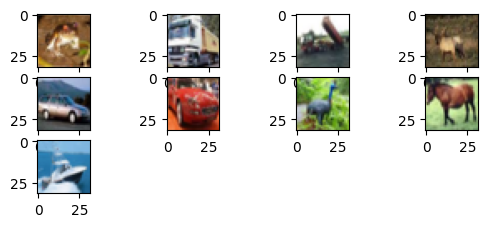

In [ ]:
# Plot the first n sample of images
# create a grid of 3x3 images
for i in range(0, 9):
	pyplot.subplot(640 + 1 + i)
	pyplot.imshow(X_train[i], cmap=pyplot.get_cmap('gray'))
pyplot.show()

## <font color= #486074> &ensp; • **Data Processing** </font>
Since we arelady have our images in the correct format (len_samples, pixels, pixels, channels) we just normalize them by dividing each pixel by 255:

In [ ]:
# Normalize them
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

## <font color= #486074> &ensp; • **AUTOENCODER v1 - 3D vector** </font>
In this first version, the autoencoder compresses each CIFAR-10 image into a 3-dimensional latent vector so that the latent space can be easily visualized, similar to what PCA does. This strong bottleneck forces the model to keep only the most important global information about each image, such as general color distributions and rough shapes.

In [ ]:
# Let´s specify the dimensions of our latent vector
latent_vec_dim = 3

# Define the shape of the expected input
input_layer = Input(shape=(32,32,3))

In [ ]:
# ENCODER
# First convolutional layer with 32 kernels of size 3x3 (batch, 32, 32, 3) -> (batch, 32, 32, 32)
enc_layer_1 = Conv2D(32, 3, activation="relu", padding="same")(input_layer) # With padding="same" and stride=1, the spatial dimensions are preserved

# Second layer MaxPooling reduces the spatial dimensions by a factor of 2 (batch, 32, 32, 32) -> (batch, 16, 16, 32)
enc_layer_2 = MaxPooling2D(2)(enc_layer_1)

# Third convolutional layer with 64 kernels of size 3x3 (batch, 16, 16, 32) -> (batch, 16, 16, 64)
enc_layer_3 = Conv2D(64, 3, activation="relu", padding="same")(enc_layer_2)

# Fourth layer MaxPooling further reduces the spatial dimensions by a factor of 2 (batch, 16, 16, 64) -> (batch, 8, 8, 64)
enc_layer_4 = MaxPooling2D(2)(enc_layer_3)

# Fifth layer to convert the 3D feature maps into a 1D vector (batch, 8, 8, 64) -> (batch, 4096)
enc_layer_5 = Flatten()(enc_layer_4)

# Latent space -> Dense layer that compresses the representation into a low-dimensional vector of 3 components (batch, 4096) -> (batch, 3)
enc_layer_6 = Dense(latent_vec_dim, name="latent_space")(enc_layer_5)

encoder = enc_layer_6

# DECODER

# Fully connected layer to expand the latent vector back to the flattened feature map size (batch, 3) -> (batch, 4096)
# Same size as the enc_layer_5 output
dec_layer_1 = Dense(8 * 8 * 64, activation="relu")(encoder)

# Reshape the vector back into 3D feature maps (batch, 4096) -> (batch, 8, 8, 64)
dec_layer_2 = Reshape((8, 8, 64))(dec_layer_1)

# Transposed convolution to upsample the feature maps (batch, 8, 8, 64) -> (batch, 16, 16, 64)
# strides=2 → double width & height [inverse of maxpooling by 2]
dec_layer_3 = Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(dec_layer_2)

# Second transposed convolution (batch, 16, 16, 64) -> (batch, 32, 32, 32)
dec_layer_4 = Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(dec_layer_3)

# Final transposed convolution to reconstruct the original image (batch, 32, 32, 32) -> (batch, 32, 32, 3)
# Sigmoid activation is used assuming input images are normalized to [0, 1]
dec_layer_5 = Conv2DTranspose(3, 3, padding="same", activation="sigmoid")(dec_layer_4)

decoder = dec_layer_5

In [ ]:
# Connect both encoder and decoder = AUTOENCODER
autoencoder = Model(input_layer, decoder, name="AE_3d")

# Latent representation = ENCODER
latent_model = Model(input_layer, encoder)

# Summary of the AE 
autoencoder.summary()

Model: "AE_2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 3)              │        12,291 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,326 (407.52 KB)

 Trainable params: 104,326 (407.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0436 - val_loss: 0.0331
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0330 - val_loss: 0.0329
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0328 - val_loss: 0.0327
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0325 - val_loss: 0.0325
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0326 - val_loss: 0.0325
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0325 - val_loss: 0.0324
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0324 - val_loss: 0.0324
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0324 - val_loss: 0.0323
Epoch 9/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0324 - val_loss: 0.0323
Epoch 10/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0324 - val_loss: 0.0323
Epoch 11/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0324 - val_loss: 0.0323
Epoch 12/15
391/391 ━━━━━━━━━━━━━━━━━━━━

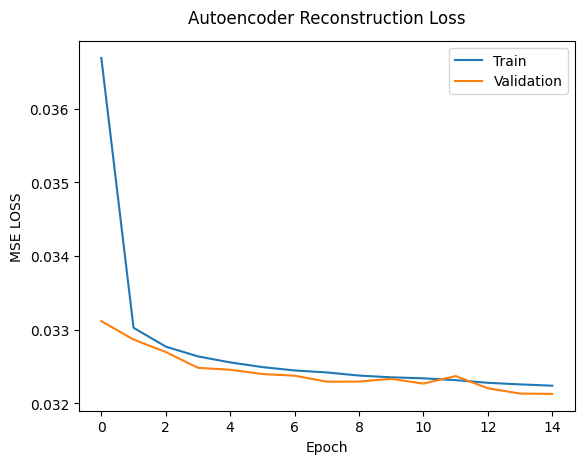

In [ ]:
# Compile the autoencoder model
# The norm is ti minimize the l2-norm
autoencoder.compile(loss='mse', optimizer='adam')

# Train the autoencoder with CIFAR10 data
history = autoencoder.fit(X_train, X_train, epochs=15, batch_size=128, shuffle=True, validation_data=(X_test, X_test))

# Plot the loss per epoch of both sets of data
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('MSE LOSS')
plt.xlabel('Epoch')
plt.title('Autoencoder Reconstruction Loss', pad=13)
plt.legend(loc='upper right')

In [ ]:
# Plot the latent representation to see clusters
y_plot = y_test.ravel() 

# Obtain our 3d representation = PCA(n=3)
Z_3d = latent_model.predict(X_test)

# Plotly 3D
fig = px.scatter_3d(
    x=Z_3d[:, 0],
    y=Z_3d[:, 1],
    z=Z_3d[:, 2],
    color=y_plot.astype(str),
    opacity=0.7,
    title="Latent Space (PCA 3D)",
    labels={
        "x": "PC1",
        "y": "PC2",
        "z": "PC3",
        "color": "Label"
    }
)

fig.update_traces(marker=dict(size=3))
fig.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


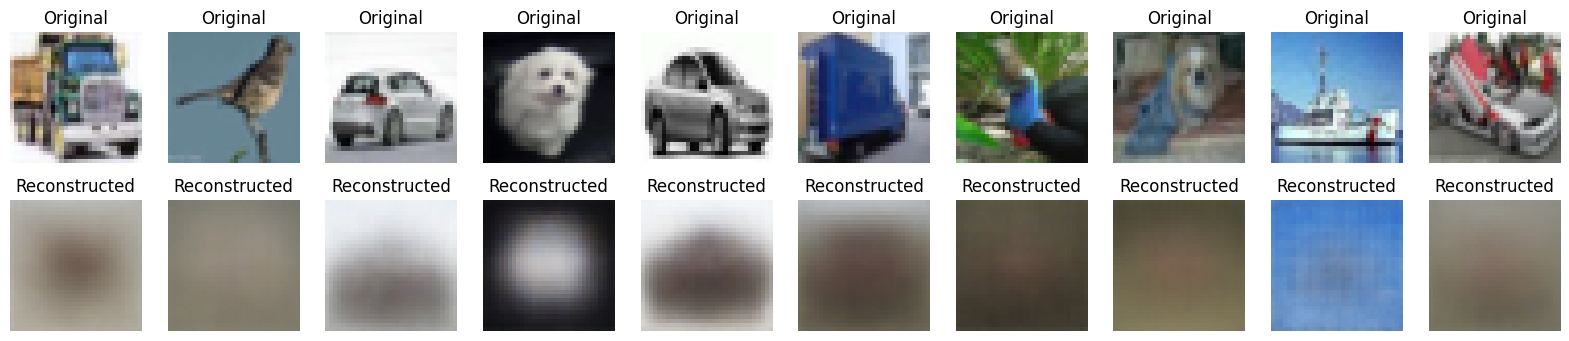

In [ ]:
# Let's reconstruct images using the autoencoder
X_recon = autoencoder.predict(X_test)

n = 10  # n random sample images
idx = np.random.choice(len(X_test), n)

plt.figure(figsize=(20, 4))

for i, id in enumerate(idx):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[id])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_recon[id])
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()


CIFAR-10 images contain much more information than can be represented in just three numbers. As a result, most fine details, textures, and sharp edges are lost during compression. When the decoder tries to reconstruct the image from this limited representation, it can only recover a rough and blurry version of the original image.

## <font color= #486074> &ensp; • **AUTOENCODER v2 - Conv bottleneck** </font>
In this second model, the autoencoder uses a fully convolutional bottleneck instead of a very low-dimensional vector. The encoder gradually reduces the spatial size of the image while increasing the number of feature channels. Unlike the previous model, this bottleneck does not force the image into just a few numbers, allowing the network to retain much more information.

In [ ]:
# ENCODER

# First convolutional layer with 32 kernels of size 3x3 (batch, 32, 32, 3) -> (batch, 32, 32, 32)
enc_layer_1 = Conv2D(32, 3, activation="relu", padding="same")(input_layer)

# Second layer a MaxPooling that reduces the spatial dimensions by a factor of 2 (batch, 32, 32, 32) -> (batch, 16, 16, 32)
enc_layer_2 = MaxPooling2D(2)(enc_layer_1)

# Third convolutional layer with 64 kernels of size 3x3 (batch, 16, 16, 32) -> (batch, 16, 16, 64)
enc_layer_3 = Conv2D(64, 3, activation="relu", padding="same")(enc_layer_2)

# Fourth layer a MaxPooling that further reduces the spatial dimensions (batch, 16, 16, 64) -> (batch, 8, 8, 64)
enc_layer_4 = MaxPooling2D(2)(enc_layer_3)

# Fifth convolutional layer increases the number of channels (batch, 8, 8, 64) -> (batch, 8, 8, 128)
enc_layer_5 = Conv2D(128, 3, activation="relu", padding="same")(enc_layer_4)

# Sixth layer a MaxPooling creates the convolutional bottleneck (batch, 8, 8, 128) -> (batch, 4, 4, 128)
enc_layer_6 = MaxPooling2D(2)(enc_layer_5)

encoder = enc_layer_6

# DECODER

# First transposed convolution upsamples the feature maps (batch, 4, 4, 128) -> (batch, 8, 8, 128)
dec_layer_1 = Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(encoder)

# Second transposed convolution upsamples and reduces the number of channels (batch, 8, 8, 128) -> (batch, 16, 16, 64)
dec_layer_2 = Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(dec_layer_1)

# Third transposed convolution upsamples further and reduces the channel dimension (batch, 16, 16, 64) -> (batch, 32, 32, 32)
dec_layer_3 = Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(dec_layer_2)

# Final transposed convolution reconstructs the original image (batch, 32, 32, 32) -> (batch, 32, 32, 3)
# Sigmoid activation assumes input images are normalized to [0, 1]
dec_layer_4 = Conv2DTranspose(3, 3, padding="same", activation="sigmoid")(dec_layer_3)

decoder = dec_layer_4

In [ ]:
# Connect both encoder and decoder
autoencoder = Model(input_layer, decoder, name="AE_Multidim")

# Latent representation (Optional)
latent_model = Model(input_layer, encoder)

# Get summary
autoencoder.summary()

Model: "DeepAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.0292 - val_loss: 0.0098
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0093 - val_loss: 0.0083
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0077 - val_loss: 0.0072
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0067 - val_loss: 0.0059
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0053 - val_loss: 0.0050
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 9/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 10/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 11/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 12/15
391/391 ━━━━━━━━━━━━━━━━━━━━

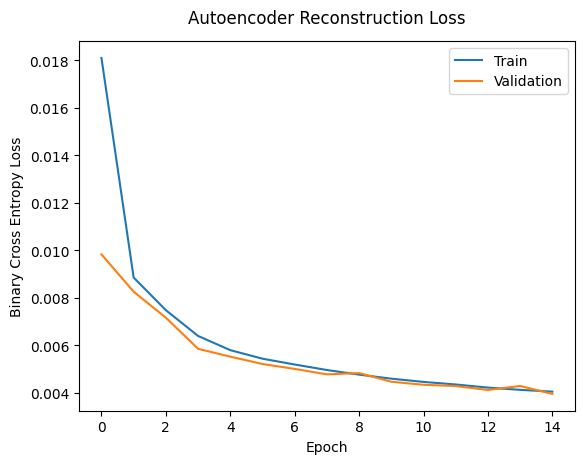

In [ ]:
# Compile the autoencoder model
# The norm is ti minimize the l2-norm
autoencoder.compile(loss='mse', optimizer='adam')

# Train the autoencoder with CIFAR10 data
history = autoencoder.fit(X_train, X_train, epochs=15, batch_size=128, shuffle=True, validation_data=(X_test, X_test))

# Plot the loss per epoch of both sets of data
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('MSE LOSS')
plt.xlabel('Epoch')
plt.title('Autoencoder Reconstruction Loss', pad=13)
plt.legend(loc='upper right')

In [ ]:
# Latent Model
latent_model = Model(input_layer, enc_layer_6)

# Latent representation
Z_conv = latent_model.predict(X_test)
print(Z_conv.shape)  # (10000, 4, 4, 128)

Z_flat = Z_conv.reshape(len(Z_conv), -1)
print(Z_flat.shape)  # (10000, 2048)

# PCA 3D
pca = PCA(n_components=3)
Z_3d = pca.fit_transform(Z_flat)
print(Z_3d.shape)  # (10000, 3)

y_plot = y_test.ravel()   

# Plotly 3D
fig = px.scatter_3d(
    x=Z_3d[:, 0],
    y=Z_3d[:, 1],
    z=Z_3d[:, 2],
    color=y_plot.astype(str),
    opacity=0.7,
    title="Latent Space (PCA 3D)",
    labels={
        "x": "PC1",
        "y": "PC2",
        "z": "PC3",
        "color": "Label"
    }
)

fig.update_traces(marker=dict(size=3))
fig.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 4, 4, 128)
(10000, 2048)
(10000, 3)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


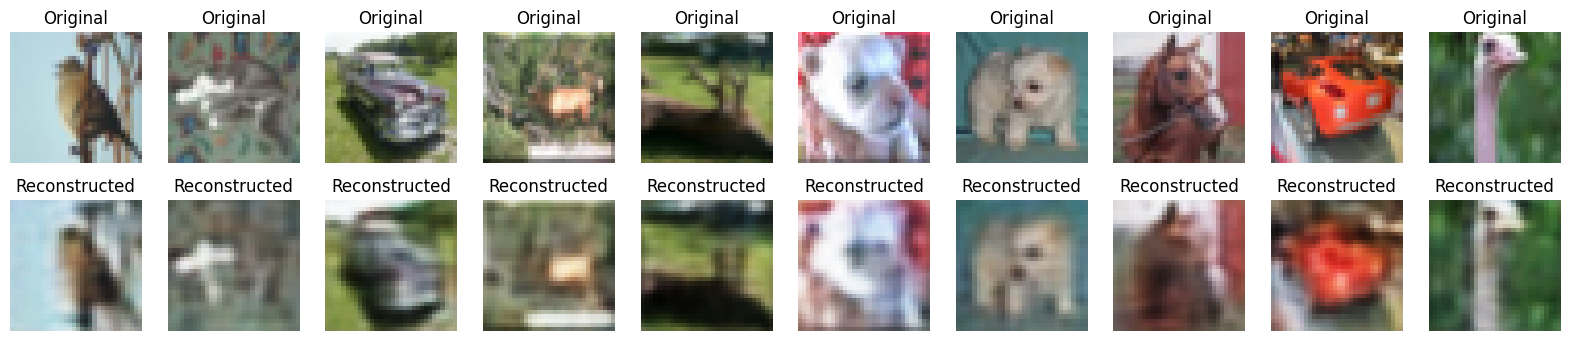

In [ ]:
# Let's reconstruct images using the autoencoder
X_recon = autoencoder.predict(X_test)

n = 10  # n random sample images
idx = np.random.choice(len(X_test), n)

plt.figure(figsize=(20, 4))

for i, id in enumerate(idx):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[id])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_recon[id])
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

The decoder is able to reconstruct images with better sharpness and structure. However, some fine details are still lost due to repeated downsampling with max pooling, which removes exact spatial information.